<a href="https://colab.research.google.com/github/Manjot0005/data266-6359/blob/GPU-Assignment1/gpu_assignment_6359.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2.5 — GPU Assignment I: Precision, Bandwidth, and the Cost of Attention




In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/hw2_5_gpu_assignment'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.chdir(OUTPUT_DIR)
print(f"Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/hw2_5_gpu_assignment


In [32]:
with open("nvidia_smi_full.txt") as f:
    print(f.read())


==============NVSMI LOG==============

Timestamp                                 : Tue Sep 22 04:01:56 2026
Driver Version                            : 580.82.07
CUDA Version                              : 13.0

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla T4
    Product Brand                         : NVIDIA
    Product Architecture                  : Turing
    Display Mode                          : Requested functionality has been deprecated
    Display Attached                      : Yes
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    Addressing Mode                       : None
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/

In [31]:
import os
print(sorted(os.listdir()))

['AI_USE.md', 'METRICS.md', 'RUN_LOG.txt', 'attention_coarse_results.json', 'attention_quad_fit.json', 'attention_speedups.json', 'bandwidth_compute_results.json', 'card_provenance.json', 'fig_attention_memory_vs_seqlen.png', 'fig_precision_tflops_vs_N.png', 'fig_thermal_clock_temp_vs_time.png', 'nvidia_smi_full.txt', 'oom_boundaries.json', 'precision_results.json', 'reservation_record.txt', 'sustained_load_summary.json', 'thermal_log.csv']


In [2]:
import torch, time, json, subprocess, os, re, sys, csv, datetime, math
import numpy as np

RUN_LOG_PATH = "RUN_LOG.txt"
_run_log_f = open(RUN_LOG_PATH, "a")

def log(msg):
    line = f"[{datetime.datetime.now().isoformat(timespec='seconds')}] {msg}"
    print(line)
    _run_log_f.write(line + "\n")
    _run_log_f.flush()

log(f"Python {sys.version}")
log(f"PyTorch {torch.__version__}, CUDA (torch) {torch.version.cuda}")

assert torch.cuda.is_available(), "No CUDA GPU visible to PyTorch — check drivers / container GPU passthrough."
device = torch.device("cuda:0")
props = torch.cuda.get_device_properties(0)
log(f"Device: {props.name}, total_mem={props.total_memory/1e9:.1f} GB, "
    f"sm={props.major}.{props.minor}, multi_processor_count={props.multi_processor_count}")


[2026-09-22T04:01:56] Python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
[2026-09-22T04:01:56] PyTorch 2.11.0+cu128, CUDA (torch) 12.8
[2026-09-22T04:01:56] Device: Tesla T4, total_mem=15.6 GB, sm=7.5, multi_processor_count=40


In [3]:
# Try to import pynvml for live clock/temp/power telemetry (Part E). Falls back gracefully if absent.
try:
    import pynvml
    pynvml.nvmlInit()
    _NVML_OK = True
except Exception as e:
    _NVML_OK = False
    log(f"pynvml unavailable ({e}); Part E will only log what nvidia-smi CLI reports.")

_nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0) if _NVML_OK else None


## Part A — Onboarding and provenance

In [4]:
smi_output = subprocess.run(["nvidia-smi", "-q"], capture_output=True, text=True).stdout
with open("nvidia_smi_full.txt", "w") as f:
    f.write(smi_output)

def grab(pattern, text, default="UNKNOWN"):
    m = re.search(pattern, text)
    return m.group(1).strip() if m else default

gpu_uuid       = grab(r"GPU UUID\s*:\s*([\w-]+)", smi_output)
driver_version = grab(r"Driver Version\s*:\s*([\d.]+)", smi_output)
cuda_version   = grab(r"CUDA Version\s*:\s*([\d.]+)", smi_output)
vram_total     = grab(r"FB Memory Usage\s*\n\s*Total\s*:\s*([\d]+ MiB)", smi_output)
power_limit    = grab(r"Power Limit\s*:\s*([\d.]+ W)", smi_output)
gpu_name_smi   = grab(r"Product Name\s*:\s*(.+)", smi_output)

log(f"GPU UUID: {gpu_uuid}")
log(f"Product name (nvidia-smi): {gpu_name_smi}")
log(f"Driver: {driver_version}, CUDA (driver): {cuda_version}, VRAM total: {vram_total}, Power limit: {power_limit}")


[2026-09-22T04:01:57] GPU UUID: GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca
[2026-09-22T04:01:57] Product name (nvidia-smi): Tesla T4
[2026-09-22T04:01:57] Driver: 580.82.07, CUDA (driver): 13.0, VRAM total: 15360 MiB, Power limit: 70.00 W


In [26]:
_run_log_f = open(RUN_LOG_PATH, "a")

CARD_PROVENANCE = {
    "gpu_uuid": gpu_uuid,
    "product_name": gpu_name_smi,
    "architecture": "NVIDIA Turing",
    "memory_type": "GDDR6",
    "memory_bandwidth_spec_GBs": 300,
    "tensor_core_generation": "1st-generation Turing Tensor Cores (320 tensor cores, 2,560 CUDA cores)",
    "supported_reduced_precisions": "['FP16','INT8','INT4'] (no TF32 or BF16 tensor-core support — those arrived with Ampere)",
    "source_citation": "NVIDIA T4 Tensor Core GPU Datasheet, https://nvidia.com/content/dam/en-zz/Solutions/Data-Center/tesla-t4/t4-tensor-core-datasheet-951643.pdf, accessed 2026-09-19",
}
with open("card_provenance.json", "w") as f:
    json.dump(CARD_PROVENANCE, f, indent=2)
log("Wrote card_provenance.json")

[2026-09-22T04:38:01] Wrote card_provenance.json


## Part B — Precision and achieved throughput


In [6]:
THEORETICAL_PEAK_TFLOPS = {"fp32": 8.1, "tf32": None, "fp16": 65.0, "bf16": None, "fp8": None}

In [7]:
def benchmark_matmul(N, mode, iters=30, warmup=10):
    """mode in {'fp32','tf32','fp16','bf16','fp8'}. Returns (tflops, avg_seconds) or raises."""
    prev_tf32_matmul = torch.backends.cuda.matmul.allow_tf32
    prev_tf32_cudnn  = torch.backends.cudnn.allow_tf32
    try:
        if mode == "fp32":
            torch.backends.cuda.matmul.allow_tf32 = False
            dtype = torch.float32
        elif mode == "tf32":
            torch.backends.cuda.matmul.allow_tf32 = True
            dtype = torch.float32  # TF32 is a compute mode on fp32 storage, not a torch dtype
        elif mode == "fp16":
            dtype = torch.float16
        elif mode == "bf16":
            dtype = torch.bfloat16
        elif mode == "fp8":
            if not hasattr(torch, "float8_e4m3fn"):
                raise RuntimeError("torch build has no float8_e4m3fn dtype")
            dtype = torch.float8_e4m3fn
        else:
            raise ValueError(mode)

        a = torch.randn(N, N, device=device, dtype=torch.float32).to(dtype)
        b = torch.randn(N, N, device=device, dtype=torch.float32).to(dtype)

        for _ in range(warmup):
            c = a @ b
        torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(iters):
            c = a @ b
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        avg_time = elapsed / iters
        flops = 2 * (N ** 3)
        tflops = flops / avg_time / 1e12
        return tflops, avg_time
    finally:
        torch.backends.cuda.matmul.allow_tf32 = prev_tf32_matmul
        torch.backends.cudnn.allow_tf32 = prev_tf32_cudnn


In [8]:
sizes = [1024, 4096, 8192, 16384]
modes = ["fp32", "tf32", "fp16", "bf16", "fp8"]
ITERS = 30

precision_results = []  # list of dicts

for mode in modes:
    for N in sizes:
        try:
            tflops, avg_t = benchmark_matmul(N, mode, iters=ITERS)
            peak = THEORETICAL_PEAK_TFLOPS.get(mode)
            pct_peak = (tflops / peak * 100) if peak else None
            precision_results.append({
                "gpu_uuid": gpu_uuid, "mode": mode, "N": N,
                "tflops": tflops, "avg_time_s": avg_t,
                "pct_of_theoretical_peak": pct_peak, "iters": ITERS, "status": "ok",
            })
            log(f"[matmul] mode={mode:5s} N={N:6d} -> {tflops:8.2f} TFLOPS ({avg_t*1e3:.3f} ms/iter)")
        except Exception as e:
            precision_results.append({
                "gpu_uuid": gpu_uuid, "mode": mode, "N": N,
                "tflops": None, "avg_time_s": None,
                "pct_of_theoretical_peak": None, "iters": ITERS,
                "status": f"FAILED: {e}",
            })
            log(f"[matmul] mode={mode:5s} N={N:6d} -> FAILED: {e}")
        torch.cuda.empty_cache()

with open("precision_results.json", "w") as f:
    json.dump(precision_results, f, indent=2)


[2026-09-22T04:01:58] [matmul] mode=fp32  N=  1024 ->     2.48 TFLOPS (0.867 ms/iter)
[2026-09-22T04:01:59] [matmul] mode=fp32  N=  4096 ->     4.19 TFLOPS (32.817 ms/iter)
[2026-09-22T04:02:10] [matmul] mode=fp32  N=  8192 ->     4.01 TFLOPS (274.239 ms/iter)
[2026-09-22T04:03:33] [matmul] mode=fp32  N= 16384 ->     4.15 TFLOPS (2118.003 ms/iter)
[2026-09-22T04:03:33] [matmul] mode=tf32  N=  1024 ->     3.58 TFLOPS (0.600 ms/iter)
[2026-09-22T04:03:35] [matmul] mode=tf32  N=  4096 ->     3.20 TFLOPS (42.921 ms/iter)
[2026-09-22T04:03:49] [matmul] mode=tf32  N=  8192 ->     3.13 TFLOPS (351.076 ms/iter)
[2026-09-22T04:05:16] [matmul] mode=tf32  N= 16384 ->     4.04 TFLOPS (2176.812 ms/iter)
[2026-09-22T04:05:16] [matmul] mode=fp16  N=  1024 ->    36.52 TFLOPS (0.059 ms/iter)
[2026-09-22T04:05:17] [matmul] mode=fp16  N=  4096 ->    18.32 TFLOPS (7.501 ms/iter)
[2026-09-22T04:05:19] [matmul] mode=fp16  N=  8192 ->    20.56 TFLOPS (53.486 ms/iter)
[2026-09-22T04:05:43] [matmul] mode=fp16 

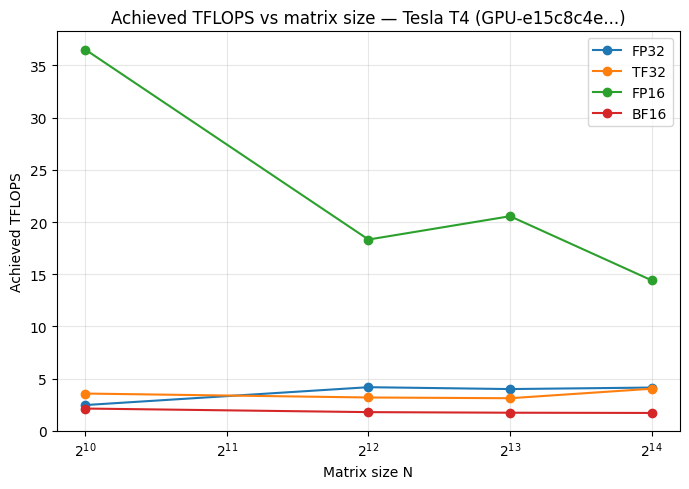

[2026-09-22T04:09:37] Saved fig_precision_tflops_vs_N.png


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
for mode in modes:
    xs, ys = [], []
    for r in precision_results:
        if r["mode"] == mode and r["status"] == "ok":
            xs.append(r["N"]); ys.append(r["tflops"])
    if xs:
        plt.plot(xs, ys, marker="o", label=mode.upper())
plt.xscale("log", base=2)
plt.xlabel("Matrix size N")
plt.ylabel("Achieved TFLOPS")
plt.title(f"Achieved TFLOPS vs matrix size — {gpu_name_smi} ({gpu_uuid[:12]}...)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_precision_tflops_vs_N.png", dpi=150)
plt.show()
log("Saved fig_precision_tflops_vs_N.png")


## Part C — Bandwidth-bound vs compute-bound



In [10]:
SPEC_BANDWIDTH_GBs = 300

def benchmark_bandwidth(n_elements=1 << 28, iters=20, warmup=5, dtype=torch.float32):
    x = torch.randn(n_elements, device=device, dtype=dtype)
    y = torch.randn(n_elements, device=device, dtype=dtype)
    for _ in range(warmup):
        z = x + y
    torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(iters):
        z = x + y
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    avg_time = elapsed / iters
    bytes_per_el = torch.tensor([], dtype=dtype).element_size()
    bytes_moved = 3 * n_elements * bytes_per_el  # read x, read y, write z
    bandwidth_GBs = bytes_moved / avg_time / 1e9
    flops = n_elements  # one add per element
    arithmetic_intensity = flops / bytes_moved
    return bandwidth_GBs, avg_time, arithmetic_intensity

bw_GBs, bw_time, bw_ai = benchmark_bandwidth()
pct_spec = (bw_GBs / SPEC_BANDWIDTH_GBs * 100) if SPEC_BANDWIDTH_GBs else None
if pct_spec is not None:
    log(f"[bandwidth] elementwise add: {bw_GBs:.1f} GB/s ({pct_spec:.1f}% of spec), AI={bw_ai:.4f} FLOP/byte")
else:
    log(f"[bandwidth] elementwise add: {bw_GBs:.1f} GB/s, AI={bw_ai:.4f} FLOP/byte (set SPEC_BANDWIDTH_GBs for % of spec)")


[2026-09-22T04:09:37] [bandwidth] elementwise add: 243.6 GB/s (81.2% of spec), AI=0.0833 FLOP/byte


In [11]:
def matmul_arithmetic_intensity(N, dtype_bytes=4):
    flops = 2 * N**3
    bytes_moved = 3 * (N**2) * dtype_bytes  # naive: read A, read B, write C (ignores cache reuse — note this as a simplification)
    return flops / bytes_moved

N_compute = 8192
compute_tflops, compute_time = benchmark_matmul(N_compute, "fp32", iters=20)
compute_ai = matmul_arithmetic_intensity(N_compute, dtype_bytes=4)

log(f"[compute] fp32 matmul N={N_compute}: {compute_tflops:.2f} TFLOPS, AI={compute_ai:.2f} FLOP/byte")
log(f"Roofline placement: bandwidth-bound kernel AI={bw_ai:.4f} << matmul AI={compute_ai:.2f} "
    f"=> elementwise add sits on the memory-bound (left, sloped) side of the roofline, "
    f"matmul at N={N_compute} sits on the compute-bound (right, flat) side, "
    f"assuming AI exceeds this card's machine balance (peak_TFLOPS / peak_bandwidth_GBs).")

with open("bandwidth_compute_results.json", "w") as f:
    json.dump({
        "gpu_uuid": gpu_uuid,
        "bandwidth_bound": {"GBs": bw_GBs, "pct_of_spec": pct_spec, "arithmetic_intensity": bw_ai},
        "compute_bound": {"N": N_compute, "tflops": compute_tflops, "arithmetic_intensity": compute_ai},
    }, f, indent=2)


[2026-09-22T04:09:47] [compute] fp32 matmul N=8192: 3.20 TFLOPS, AI=1365.33 FLOP/byte
[2026-09-22T04:09:47] Roofline placement: bandwidth-bound kernel AI=0.0833 << matmul AI=1365.33 => elementwise add sits on the memory-bound (left, sloped) side of the roofline, matmul at N=8192 sits on the compute-bound (right, flat) side, assuming AI exceeds this card's machine balance (peak_TFLOPS / peak_bandwidth_GBs).


## Part D — The cost of attention




In [12]:
import torch.nn.functional as F

BATCH = 1
HEAD_DIM = 64
N_HEADS = 8
DTYPE_ATTN = torch.float16  # fp16 for headroom; note this choice in your writeup

def make_qkv(seq_len, dtype=DTYPE_ATTN):
    shape = (BATCH, N_HEADS, seq_len, HEAD_DIM)
    q = torch.randn(shape, device=device, dtype=dtype)
    k = torch.randn(shape, device=device, dtype=dtype)
    v = torch.randn(shape, device=device, dtype=dtype)
    return q, k, v

def naive_attention(q, k, v):
    scale = 1.0 / math.sqrt(q.shape[-1])
    scores = (q @ k.transpose(-2, -1)) * scale        # (B, H, S, S) materialized explicitly
    attn = torch.softmax(scores, dim=-1)
    out = attn @ v
    return out

def measure_attention(seq_len, fused, iters=10, warmup=3):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    q, k, v = make_qkv(seq_len)
    fn = (lambda q, k, v: F.scaled_dot_product_attention(q, k, v)) if fused else naive_attention
    for _ in range(warmup):
        out = fn(q, k, v)
    torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(iters):
        out = fn(q, k, v)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    avg_latency = elapsed / iters
    peak_mem = torch.cuda.max_memory_allocated() / 1e6  # MB
    del q, k, v, out
    torch.cuda.empty_cache()
    return peak_mem, avg_latency


In [13]:
seq_lengths = [512, 1024, 2048, 4096, 8192, 16384]

attn_results = {"naive": [], "fused": []}

for fused, key in [(False, "naive"), (True, "fused")]:
    for S in seq_lengths:
        try:
            mem_MB, lat_s = measure_attention(S, fused=fused)
            attn_results[key].append({"gpu_uuid": gpu_uuid, "seq_len": S,
                                       "peak_mem_MB": mem_MB, "latency_s": lat_s, "status": "ok"})
            log(f"[attn:{key}] S={S:6d} -> {mem_MB:9.1f} MB, {lat_s*1e3:8.2f} ms")
        except torch.cuda.OutOfMemoryError as e:
            attn_results[key].append({"gpu_uuid": gpu_uuid, "seq_len": S,
                                       "peak_mem_MB": None, "latency_s": None, "status": "OOM"})
            log(f"[attn:{key}] S={S:6d} -> OOM")
            torch.cuda.empty_cache()

with open("attention_coarse_results.json", "w") as f:
    json.dump(attn_results, f, indent=2)


[2026-09-22T04:09:47] [attn:naive] S=   512 ->      19.5 MB,     0.16 ms
[2026-09-22T04:09:47] [attn:naive] S=  1024 ->      47.3 MB,     0.60 ms
[2026-09-22T04:09:47] [attn:naive] S=  2048 ->     153.2 MB,     2.02 ms
[2026-09-22T04:09:48] [attn:naive] S=  4096 ->     566.4 MB,    10.11 ms
[2026-09-22T04:09:48] [attn:naive] S=  8192 ->    2197.9 MB,    39.16 ms
[2026-09-22T04:09:50] [attn:naive] S= 16384 ->    8682.3 MB,   146.66 ms
[2026-09-22T04:09:50] [attn:fused] S=   512 ->      11.1 MB,     0.07 ms
[2026-09-22T04:09:50] [attn:fused] S=  1024 ->      13.8 MB,     0.21 ms
[2026-09-22T04:09:50] [attn:fused] S=  2048 ->      19.0 MB,     0.64 ms
[2026-09-22T04:09:50] [attn:fused] S=  4096 ->      29.5 MB,     2.45 ms
[2026-09-22T04:09:50] [attn:fused] S=  8192 ->      50.5 MB,    12.17 ms
[2026-09-22T04:09:51] [attn:fused] S= 16384 ->      92.4 MB,    46.04 ms


In [14]:
def find_oom_boundary(fused, lo, hi, step=1):
    """Binary-search between the largest known-good `lo` and smallest known-OOM `hi`
    (both seq lengths) to find, at `step` resolution, the largest S that succeeds and the
    smallest S that fails. Returns (largest_ok, smallest_oom)."""
    def ok(S):
        try:
            measure_attention(S, fused=fused, iters=1, warmup=1)
            torch.cuda.empty_cache()
            return True
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            return False

    largest_ok, smallest_oom = lo, hi
    while smallest_oom - largest_ok > step:
        mid = (largest_ok + smallest_oom) // 2
        mid -= mid % step  # keep on a clean grid if step > 1
        if mid == largest_ok:
            break
        if ok(mid):
            largest_ok = mid
        else:
            smallest_oom = mid
    return largest_ok, smallest_oom

MAX_SEQ_LEN_TO_TRY = 65536  # hard cap so an auto-extending search can't run forever

def find_coarse_oom(fused, start_seq_len, cap=MAX_SEQ_LEN_TO_TRY):
    """Coarse sweep never hit OOM within the assignment's required range (this can happen
    on large-VRAM cards). Doubles seq_len from the largest tested value until something OOMs
    or the cap is hit. Returns (largest_ok, smallest_oom) where smallest_oom may be None if
    the cap was reached without OOMing -- itself a legitimate, reportable finding."""
    largest_ok = start_seq_len
    S = start_seq_len
    while S < cap:
        S = min(S * 2, cap)
        try:
            measure_attention(S, fused=fused, iters=1, warmup=1)
            torch.cuda.empty_cache()
            largest_ok = S
            log(f"[oom-extend:{'fused' if fused else 'naive'}] S={S} -> ok, still extending")
            if S == cap:
                break
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            log(f"[oom-extend:{'fused' if fused else 'naive'}] S={S} -> OOM")
            return largest_ok, S
    return largest_ok, None  # never OOM'd up to cap

oom_boundaries = {}
for fused, key in [(False, "naive"), (True, "fused")]:
    oks  = [r["seq_len"] for r in attn_results[key] if r["status"] == "ok"]
    booms = [r["seq_len"] for r in attn_results[key] if r["status"] == "OOM"]
    if oks and booms:
        lo, hi = max(oks), min(booms)
        largest_ok, smallest_oom = find_oom_boundary(fused, lo, hi, step=1)
        oom_boundaries[key] = {"largest_ok": largest_ok, "smallest_oom": smallest_oom,
                                "note": "OOM boundary found within the required coarse sweep range"}
        log(f"[oom:{key}] largest_ok={largest_ok}, smallest_oom={smallest_oom}")
    elif oks and not booms:
        # Nothing OOM'd within 512-16384 (plenty of VRAM for this range) -- extend the sweep
        # upward until we find the real boundary, or hit MAX_SEQ_LEN_TO_TRY.
        start = max(oks)
        log(f"[oom:{key}] no OOM by S={start} in the required sweep — auto-extending upward")
        largest_ok_ext, smallest_oom_ext = find_coarse_oom(fused, start)
        if smallest_oom_ext is not None:
            largest_ok, smallest_oom = find_oom_boundary(fused, largest_ok_ext, smallest_oom_ext, step=1)
            oom_boundaries[key] = {"largest_ok": largest_ok, "smallest_oom": smallest_oom,
                                    "note": f"required sweep never OOM'd; boundary found by extending past S={start}"}
            log(f"[oom:{key}] largest_ok={largest_ok}, smallest_oom={smallest_oom} (extended sweep)")
        else:
            oom_boundaries[key] = {"largest_ok": largest_ok_ext, "smallest_oom": None,
                                    "note": f"did not OOM up to the {MAX_SEQ_LEN_TO_TRY} cap — report this as-is; "
                                            f"do not claim a boundary that wasn't observed"}
            log(f"[oom:{key}] no OOM found up to cap {MAX_SEQ_LEN_TO_TRY}")
    else:
        oom_boundaries[key] = {"largest_ok": max(oks) if oks else None,
                                "smallest_oom": min(booms) if booms else None,
                                "note": "unexpected: OOM'd before any success — check HEAD_DIM/N_HEADS/BATCH or GPU memory pressure from other processes"}
        log(f"[oom:{key}] {oom_boundaries[key]}")

with open("oom_boundaries.json", "w") as f:
    json.dump(oom_boundaries, f, indent=2)


[2026-09-22T04:09:51] [oom:naive] no OOM by S=16384 in the required sweep — auto-extending upward
[2026-09-22T04:09:51] [oom-extend:naive] S=32768 -> OOM
[2026-09-22T04:10:01] [oom:naive] largest_ok=21908, smallest_oom=21909 (extended sweep)
[2026-09-22T04:10:01] [oom:fused] no OOM by S=16384 in the required sweep — auto-extending upward
[2026-09-22T04:10:02] [oom-extend:fused] S=32768 -> ok, still extending
[2026-09-22T04:10:03] [oom-extend:fused] S=65536 -> ok, still extending
[2026-09-22T04:10:03] [oom:fused] no OOM found up to cap 65536


[2026-09-22T04:10:03] [fit] naive attention peak_mem(S) ~ 3.200e-05*S^2 + 5.120e-03*S + 8.520e+00  (MB)


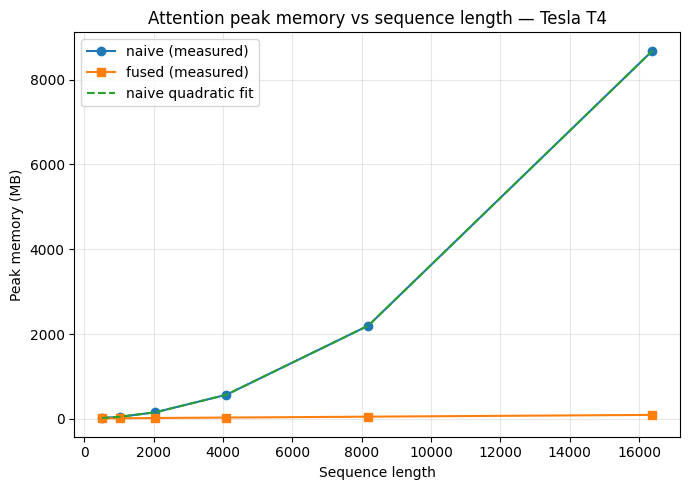

[2026-09-22T04:10:04] Saved fig_attention_memory_vs_seqlen.png


In [15]:
# Fit peak memory (naive) vs seq_len to a quadratic and report the measured coefficient.
xs = np.array([r["seq_len"] for r in attn_results["naive"] if r["status"] == "ok"], dtype=float)
ys = np.array([r["peak_mem_MB"] for r in attn_results["naive"] if r["status"] == "ok"], dtype=float)

quad_fit = None
if len(xs) >= 3:
    coeffs = np.polyfit(xs, ys, 2)  # [a, b, c] for a*x^2 + b*x + c
    quad_fit = {"a_quadratic_coeff_MB_per_S2": coeffs[0], "b": coeffs[1], "c": coeffs[2]}
    log(f"[fit] naive attention peak_mem(S) ~ {coeffs[0]:.3e}*S^2 + {coeffs[1]:.3e}*S + {coeffs[2]:.3e}  (MB)")
else:
    log("[fit] not enough non-OOM points to fit a quadratic — widen seq_lengths toward smaller S")

plt.figure(figsize=(7,5))
plt.plot(xs, ys, "o-", label="naive (measured)")
fx = np.array([r["seq_len"] for r in attn_results["fused"] if r["status"] == "ok"], dtype=float)
fy = np.array([r["peak_mem_MB"] for r in attn_results["fused"] if r["status"] == "ok"], dtype=float)
if len(fx):
    plt.plot(fx, fy, "s-", label="fused (measured)")
if quad_fit:
    fit_curve = np.polyval([quad_fit["a_quadratic_coeff_MB_per_S2"], quad_fit["b"], quad_fit["c"]], xs)
    plt.plot(xs, fit_curve, "--", label="naive quadratic fit")
plt.xlabel("Sequence length")
plt.ylabel("Peak memory (MB)")
plt.title(f"Attention peak memory vs sequence length — {gpu_name_smi}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_attention_memory_vs_seqlen.png", dpi=150)
plt.show()

with open("attention_quad_fit.json", "w") as f:
    json.dump(quad_fit, f, indent=2)
log("Saved fig_attention_memory_vs_seqlen.png")


In [16]:
# Speedup table: fused vs naive at each seq_len where both succeeded.
speedups = []
naive_by_S = {r["seq_len"]: r for r in attn_results["naive"]}
fused_by_S = {r["seq_len"]: r for r in attn_results["fused"]}
for S in seq_lengths:
    n, f = naive_by_S.get(S), fused_by_S.get(S)
    if n and f and n["status"] == "ok" and f["status"] == "ok":
        speedup = n["latency_s"] / f["latency_s"]
        speedups.append({"seq_len": S, "naive_ms": n["latency_s"]*1e3,
                          "fused_ms": f["latency_s"]*1e3, "speedup_x": speedup})
        log(f"[speedup] S={S:6d}  naive={n['latency_s']*1e3:8.2f}ms  fused={f['latency_s']*1e3:8.2f}ms  {speedup:5.2f}x")

with open("attention_speedups.json", "w") as f:
    json.dump(speedups, f, indent=2)


[2026-09-22T04:10:04] [speedup] S=   512  naive=    0.16ms  fused=    0.07ms   2.24x
[2026-09-22T04:10:04] [speedup] S=  1024  naive=    0.60ms  fused=    0.21ms   2.84x
[2026-09-22T04:10:04] [speedup] S=  2048  naive=    2.02ms  fused=    0.64ms   3.18x
[2026-09-22T04:10:04] [speedup] S=  4096  naive=   10.11ms  fused=    2.45ms   4.12x
[2026-09-22T04:10:04] [speedup] S=  8192  naive=   39.16ms  fused=   12.17ms   3.22x
[2026-09-22T04:10:04] [speedup] S= 16384  naive=  146.66ms  fused=   46.04ms   3.19x


## Part E — Sustained load and thermal behaviour


In [17]:
DURATION_SECONDS = 20 * 60   # set to e.g. 60 for a quick smoke test before the real run
SAMPLE_INTERVAL_S = 5
BENCH_N = 8192  # matmul size for the sustained load — pick something that saturates the card

def sample_nvml():
    if not _NVML_OK:
        return None
    clk_sm  = pynvml.nvmlDeviceGetClockInfo(_nvml_handle, pynvml.NVML_CLOCK_SM)
    clk_mem = pynvml.nvmlDeviceGetClockInfo(_nvml_handle, pynvml.NVML_CLOCK_MEM)
    temp    = pynvml.nvmlDeviceGetTemperature(_nvml_handle, pynvml.NVML_TEMPERATURE_GPU)
    power_w = pynvml.nvmlDeviceGetPowerUsage(_nvml_handle) / 1000.0
    util    = pynvml.nvmlDeviceGetUtilizationRates(_nvml_handle).gpu
    return dict(clock_sm_MHz=clk_sm, clock_mem_MHz=clk_mem, temp_C=temp, power_W=power_w, util_pct=util)


In [33]:
import pandas as pd
df = pd.read_csv("thermal_log.csv")
print(df.shape)
df.head(10)

(240, 10)


,t_offset_s,gpu_uuid,throughput_TFLOPS,iters_in_window,window_dt_s,clock_sm_MHz,clock_mem_MHz,temp_C,power_W,util_pct
0,5.051793,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.676541,95,5.051793,570,5000,77,65.666,100
1,10.040541,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.497043,93,4.988748,555,5000,77,66.741,100
2,15.018066,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.543260,93,4.977525,570,5000,77,67.579,100
3,20.007742,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.493228,93,4.989677,570,5000,77,65.960,100
4,25.048676,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.502965,94,5.040934,555,5000,77,65.569,100
5,30.032649,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.516683,93,4.983972,555,5000,77,65.120,100
6,35.010710,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.541046,93,4.978061,570,5000,77,66.546,100
7,40.048076,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.517486,94,5.037366,570,5000,77,66.057,100
8,45.034851,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.505151,93,4.986775,555,5000,77,67.425,100
9,50.019687,GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca,20.513130,93,4.984836,570,5000,77,66.839,99


In [35]:
import csv

with open("thermal_log.csv", newline="") as f:
    reader = csv.reader(f)
    rows = list(reader)

print(f"Total rows (including header): {len(rows)}")
print("Header:", rows[0])
print("First data row:", rows[1])
print("Last data row:", rows[-1])

Total rows (including header): 241
Header: ['t_offset_s', 'gpu_uuid', 'throughput_TFLOPS', 'iters_in_window', 'window_dt_s', 'clock_sm_MHz', 'clock_mem_MHz', 'temp_C', 'power_W', 'util_pct']
First data row: ['5.051793023999835', 'GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca', '20.67654081283347', '95', '5.051793023999835', '570', '5000', '77', '65.666', '100']
Last data row: ['1200.010182521', 'GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca', '20.562860604917336', '93', '4.972779972000353', '570', '5000', '77', '67.328', '100']


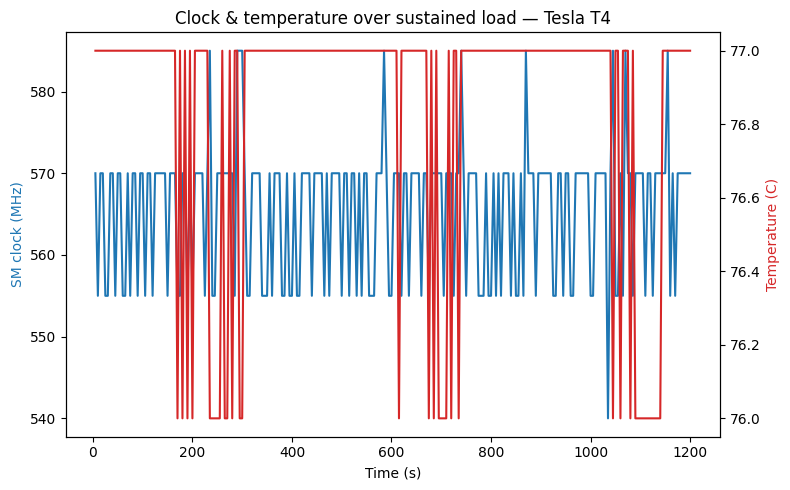

[2026-09-22T05:13:19] Saved fig_thermal_clock_temp_vs_time.png
[2026-09-22T05:13:19] [throttle-check] settled loaded clock baseline (t=10-60s): 570 MHz
[2026-09-22T05:13:19] [sustained] {'gpu_uuid': 'GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca', 'peak_tflops_first_30s': 20.67654081283347, 'steady_state_tflops_final_5min': 20.572185463848115, 'steady_pct_of_peak': 99.49529590113747, 'throttle_onset_s': None}


In [34]:
import csv

if "thermal_log" not in dir() or not thermal_log:
    with open("thermal_log.csv") as f:
        reader = csv.DictReader(f)
        thermal_log = []
        for row in reader:
            row["t_offset_s"] = float(row["t_offset_s"])
            row["throughput_TFLOPS"] = float(row["throughput_TFLOPS"])
            row["clock_sm_MHz"] = int(row["clock_sm_MHz"]) if row["clock_sm_MHz"] else None
            row["clock_mem_MHz"] = int(row["clock_mem_MHz"]) if row["clock_mem_MHz"] else None
            row["temp_C"] = int(row["temp_C"]) if row["temp_C"] else None
            row["power_W"] = float(row["power_W"]) if row["power_W"] else None
            row["util_pct"] = int(row["util_pct"]) if row["util_pct"] else None
            thermal_log.append(row)
    log(f"Reloaded thermal_log from thermal_log.csv ({len(thermal_log)} samples).")

if "DURATION_SECONDS" not in dir():
    DURATION_SECONDS = 20 * 60

if thermal_log:
    ts = [r["t_offset_s"] for r in thermal_log]
    clocks = [r.get("clock_sm_MHz") for r in thermal_log]
    temps = [r.get("temp_C") for r in thermal_log]

    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.plot(ts, clocks, color="tab:blue", label="SM clock (MHz)")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("SM clock (MHz)", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(ts, temps, color="tab:red", label="Temp (C)")
    ax2.set_ylabel("Temperature (C)", color="tab:red")
    plt.title(f"Clock & temperature over sustained load — {gpu_name_smi}")
    fig.tight_layout()
    plt.savefig("fig_thermal_clock_temp_vs_time.png", dpi=150)
    plt.show()
    log("Saved fig_thermal_clock_temp_vs_time.png")

    early = [r["throughput_TFLOPS"] for r in thermal_log if r["t_offset_s"] <= 30]
    late  = [r["throughput_TFLOPS"] for r in thermal_log if r["t_offset_s"] >= DURATION_SECONDS - 300]
    peak_tflops = max(early) if early else None
    steady_tflops = (sum(late)/len(late)) if late else None
    pct_of_peak = (steady_tflops / peak_tflops * 100) if (peak_tflops and steady_tflops) else None

    WARMUP_SKIP_S = 10
    THROTTLE_DROP_FRAC = 0.08
    THROTTLE_MIN_CONSECUTIVE = 4

    throttle_onset_s = None
    baseline_samples = [r["clock_sm_MHz"] for r in thermal_log
                        if r.get("clock_sm_MHz") is not None and WARMUP_SKIP_S <= r["t_offset_s"] <= 60]
    loaded_clock = max(baseline_samples) if baseline_samples else None

    if loaded_clock is not None:
        threshold = loaded_clock * (1 - THROTTLE_DROP_FRAC)
        consecutive_low = 0
        run_start_t = None
        for r in thermal_log:
            if r["t_offset_s"] < WARMUP_SKIP_S:
                continue
            clk = r.get("clock_sm_MHz")
            if clk is not None and clk < threshold:
                if consecutive_low == 0:
                    run_start_t = r["t_offset_s"]
                consecutive_low += 1
                if consecutive_low >= THROTTLE_MIN_CONSECUTIVE:
                    throttle_onset_s = run_start_t
                    break
            else:
                consecutive_low = 0
        log(f"[throttle-check] settled loaded clock baseline (t={WARMUP_SKIP_S}-60s): {loaded_clock} MHz")

    sustained_summary = {
        "gpu_uuid": gpu_uuid,
        "peak_tflops_first_30s": peak_tflops,
        "steady_state_tflops_final_5min": steady_tflops,
        "steady_pct_of_peak": pct_of_peak,
        "throttle_onset_s": throttle_onset_s,
    }
    with open("sustained_load_summary.json", "w") as f:
        json.dump(sustained_summary, f, indent=2)
    log(f"[sustained] {sustained_summary}")
else:
    log("No thermal samples collected — check NVML availability / DURATION_SECONDS.")

In [19]:
import os
print(os.listdir())

['RUN_LOG.txt', 'nvidia_smi_full.txt', 'precision_results.json', 'fig_precision_tflops_vs_N.png', 'bandwidth_compute_results.json', 'attention_coarse_results.json', 'oom_boundaries.json', 'fig_attention_memory_vs_seqlen.png', 'attention_quad_fit.json', 'attention_speedups.json', 'thermal_log.csv']


## Part F — Analysis: summary table



In [30]:
def best_bf16_tflops():
    rows = [r for r in precision_results if r["mode"] == "bf16" and r["status"] == "ok"]
    return max((r["tflops"] for r in rows), default=None), \
           max((r["pct_of_theoretical_peak"] for r in rows if r["pct_of_theoretical_peak"] is not None), default=None)

bf16_peak_tflops, bf16_pct_peak = best_bf16_tflops()

summary_row = {
    "Peak achieved TFLOPS (BF16)": bf16_peak_tflops,
    "% of theoretical peak (BF16)": bf16_pct_peak,
    "Effective bandwidth (GB/s)": bw_GBs,
    "Naive attention OOM length": oom_boundaries.get("naive", {}).get("smallest_oom"),
    "Fused attention OOM length": oom_boundaries.get("fused", {}).get("smallest_oom"),
    "Steady-state / peak throughput": sustained_summary.get("steady_pct_of_peak") if 'sustained_summary' in dir() else None,
    "Throttle onset (s, or none)": sustained_summary.get("throttle_onset_s") if 'sustained_summary' in dir() else None,
}

md_lines = [
    "# METRICS.md — HW2.5 GPU Assignment I",
    "",
    f"GPU: {gpu_name_smi}  ",
    f"UUID: `{gpu_uuid}`  ",
    f"Driver: {driver_version}  CUDA: {cuda_version}  VRAM: {vram_total}",
    "",
    "## Table HW2.5.1 — Summary",
    "",
    "| Measurement | Value | Notes |",
    "|---|---|---|",
]
notes = {
    "Peak achieved TFLOPS (BF16)": "None if card has no BF16 tensor cores (see Part B)",
    "% of theoretical peak (BF16)": "Requires THEORETICAL_PEAK_TFLOPS['bf16'] filled in",
    "Effective bandwidth (GB/s)": "Elementwise add, see Part C",
    "Naive attention OOM length": "Smallest failing seq_len from binary search",
    "Fused attention OOM length": "Smallest failing seq_len from binary search",
    "Steady-state / peak throughput": "Final 5 min vs first 30 s, sustained load",
    "Throttle onset (s, or none)": "First clock drop >5% below early clock",
}
for k, v in summary_row.items():
    md_lines.append(f"| {k} | {v} | {notes.get(k,'')} |")

with open("METRICS.md", "w") as f:
    f.write("\n".join(md_lines))

log("Wrote METRICS.md")
print("\n".join(md_lines))


[2026-09-22T04:45:00] Wrote METRICS.md
# METRICS.md — HW2.5 GPU Assignment I

GPU: Tesla T4  
UUID: `GPU-e15c8c4e-76ba-4cd3-6dd6-3302435da6ca`  
Driver: 580.82.07  CUDA: 13.0  VRAM: 15360 MiB

## Table HW2.5.1 — Summary

| Measurement | Value | Notes |
|---|---|---|
| Peak achieved TFLOPS (BF16) | 2.144151065468041 | None if card has no BF16 tensor cores (see Part B) |
| % of theoretical peak (BF16) | None | Requires THEORETICAL_PEAK_TFLOPS['bf16'] filled in |
| Effective bandwidth (GB/s) | 243.6181243647799 | Elementwise add, see Part C |
| Naive attention OOM length | 21909 | Smallest failing seq_len from binary search |
| Fused attention OOM length | None | Smallest failing seq_len from binary search |
| Steady-state / peak throughput | 99.49529590113747 | Final 5 min vs first 30 s, sustained load |
| Throttle onset (s, or none) | None | First clock drop >5% below early clock |
